# RiskOptima

In [18]:
!pip install --upgrade riskoptima

  Attempting uninstall: riskoptima
    Found existing installation: riskoptima 1.37.0
    Uninstalling riskoptima-1.37.0:
      Successfully uninstalled riskoptima-1.37.0


In [1]:
import pandas as pd
from riskoptima import RiskOptima

import warnings
warnings.filterwarnings(
    "ignore", 
    category=FutureWarning, 
    message=".*DataFrame.std with axis=None is deprecated.*"
)

# Define your current porfolio with your weights and company names
asset_data = [
    {"Asset": "MO",    "Weight": 0.04, "Label": "Altria Group Inc.",       "MarketCap": 110.0e9},
    {"Asset": "NWN",   "Weight": 0.14, "Label": "Northwest Natural Gas",   "MarketCap": 1.8e9},
    {"Asset": "BKH",   "Weight": 0.01, "Label": "Black Hills Corp.",         "MarketCap": 4.5e9},
    {"Asset": "ED",    "Weight": 0.01, "Label": "Con Edison",                "MarketCap": 30.0e9},
    {"Asset": "PEP",   "Weight": 0.09, "Label": "PepsiCo Inc.",              "MarketCap": 255.0e9},
    {"Asset": "NFG",   "Weight": 0.16, "Label": "National Fuel Gas",         "MarketCap": 5.6e9},
    {"Asset": "KO",    "Weight": 0.06, "Label": "Coca-Cola Company",         "MarketCap": 275.0e9},
    {"Asset": "FRT",   "Weight": 0.28, "Label": "Federal Realty Inv. Trust", "MarketCap": 9.8e9},
    {"Asset": "GPC",   "Weight": 0.16, "Label": "Genuine Parts Co.",         "MarketCap": 25.3e9},
    {"Asset": "MSEX",  "Weight": 0.05, "Label": "Middlesex Water Co.",       "MarketCap": 2.4e9}
]
asset_table = pd.DataFrame(asset_data)

capital = 100_000

asset_table['Portfolio'] = asset_table['Weight'] * capital

ANALYSIS_START_DATE = RiskOptima.get_previous_year_date(RiskOptima.get_previous_working_day(), 1)
ANALYSIS_END_DATE   = RiskOptima.get_previous_working_day()
BENCHMARK_INDEX     = 'SPY'
RISK_FREE_RATE      = 0.05
NUMBER_OF_WEIGHTS   = 10_000
NUMBER_OF_MC_RUNS   = 1_000

print(asset_table)
print(RiskOptima.VERSION)

  Asset  Weight                      Label     MarketCap  Portfolio
0    MO    0.04          Altria Group Inc.  1.100000e+11     4000.0
1   NWN    0.14      Northwest Natural Gas  1.800000e+09    14000.0
2   BKH    0.01          Black Hills Corp.  4.500000e+09     1000.0
3    ED    0.01                 Con Edison  3.000000e+10     1000.0
4   PEP    0.09               PepsiCo Inc.  2.550000e+11     9000.0
5   NFG    0.16          National Fuel Gas  5.600000e+09    16000.0
6    KO    0.06          Coca-Cola Company  2.750000e+11     6000.0
7   FRT    0.28  Federal Realty Inv. Trust  9.800000e+09    28000.0
8   GPC    0.16          Genuine Parts Co.  2.530000e+10    16000.0
9  MSEX    0.05        Middlesex Water Co.  2.400000e+09     5000.0
2.0.0


# Create Correlation Matrix

C:\repo\portfolio_risk_kit\riskoptima\riskoptima.py:3440: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download(tickers, start=start_date, end=end_date, progress=False)['Close']
C:\repo\portfolio_risk_kit\riskoptima\riskoptima.py:3443: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = price_data.pct_change().dropna()


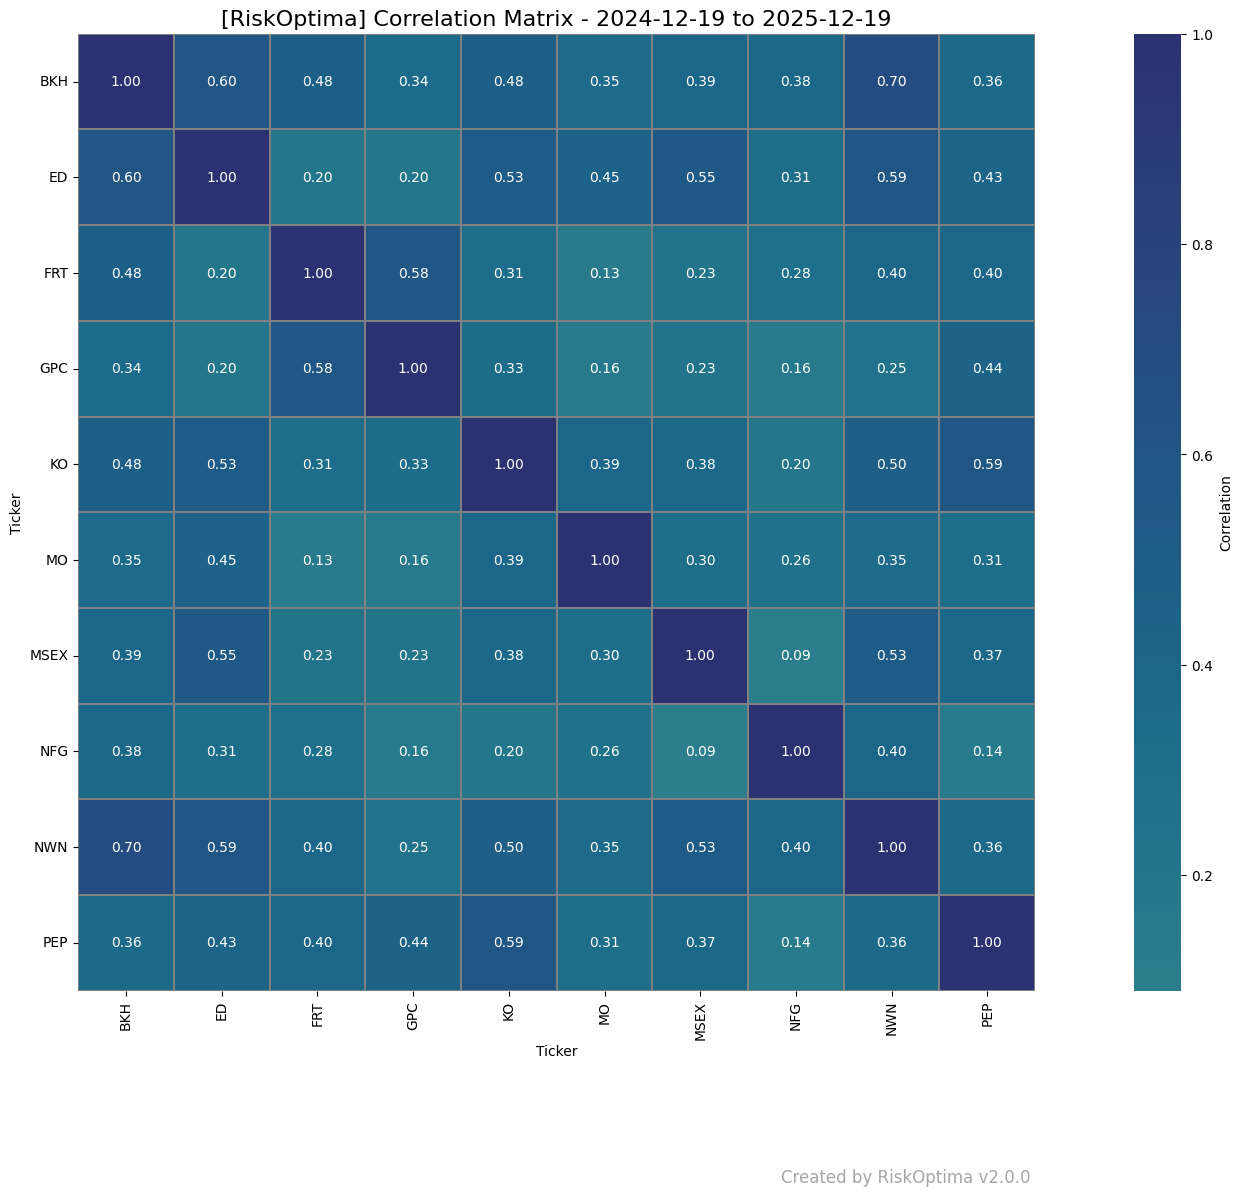

Ticker,BKH,ED,FRT,GPC,KO,MO,MSEX,NFG,NWN,PEP
Ticker,,,,,,,,,,
BKH,1.000000,0.598131,0.476705,0.341316,0.483254,0.354404,0.387937,0.382364,0.699067,0.361636
ED,0.598131,1.000000,0.202619,0.195428,0.529465,0.450625,0.552042,0.306163,0.588193,0.430396
FRT,0.476705,0.202619,1.000000,0.576133,0.309763,0.129709,0.227476,0.277563,0.399024,0.399829
GPC,0.341316,0.195428,0.576133,1.000000,0.325173,0.161499,0.231535,0.156267,0.245772,0.438543
KO,0.483254,0.529465,0.309763,0.325173,1.000000,0.386723,0.382629,0.199365,0.497810,0.592559
MO,0.354404,0.450625,0.129709,0.161499,0.386723,1.000000,0.303072,0.256998,0.350877,0.306533
MSEX,0.387937,0.552042,0.227476,0.231535,0.382629,0.303072,1.000000,0.090173,0.529706,0.367961
NFG,0.382364,0.306163,0.277563,0.156267,0.199365,0.256998,0.090173,1.000000,0.396177,0.139190
NWN,0.699067,0.588193,0.399024,0.245772,0.497810,0.350877,0.529706,0.396177,1.000000,0.361453


In [4]:
RiskOptima.build_correlation_matrix(asset_table, ANALYSIS_START_DATE, ANALYSIS_END_DATE)

## Create Portfolio Area Chart

C:\repo\portfolio_risk_kit\riskoptima\riskoptima.py:2396: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(


  Asset  Close(T-2)    Close(T)  2d % Change
0    MO   70.589996   68.930000    -2.351602
1   NWN  100.209999   99.989998    -0.219540
2   BKH  101.699997  101.650002    -0.049160
3    ED  128.059998  125.930000    -1.663281
4   PEP   70.669998   70.360001    -0.438655
5   NFG   59.180000   58.389999    -1.334912
6    KO   53.410000   53.520000     0.205955
7   FRT   82.099998   82.160004     0.073088
8   GPC   47.400002   47.459999     0.126577
9  MSEX  150.080002  149.369995    -0.473085


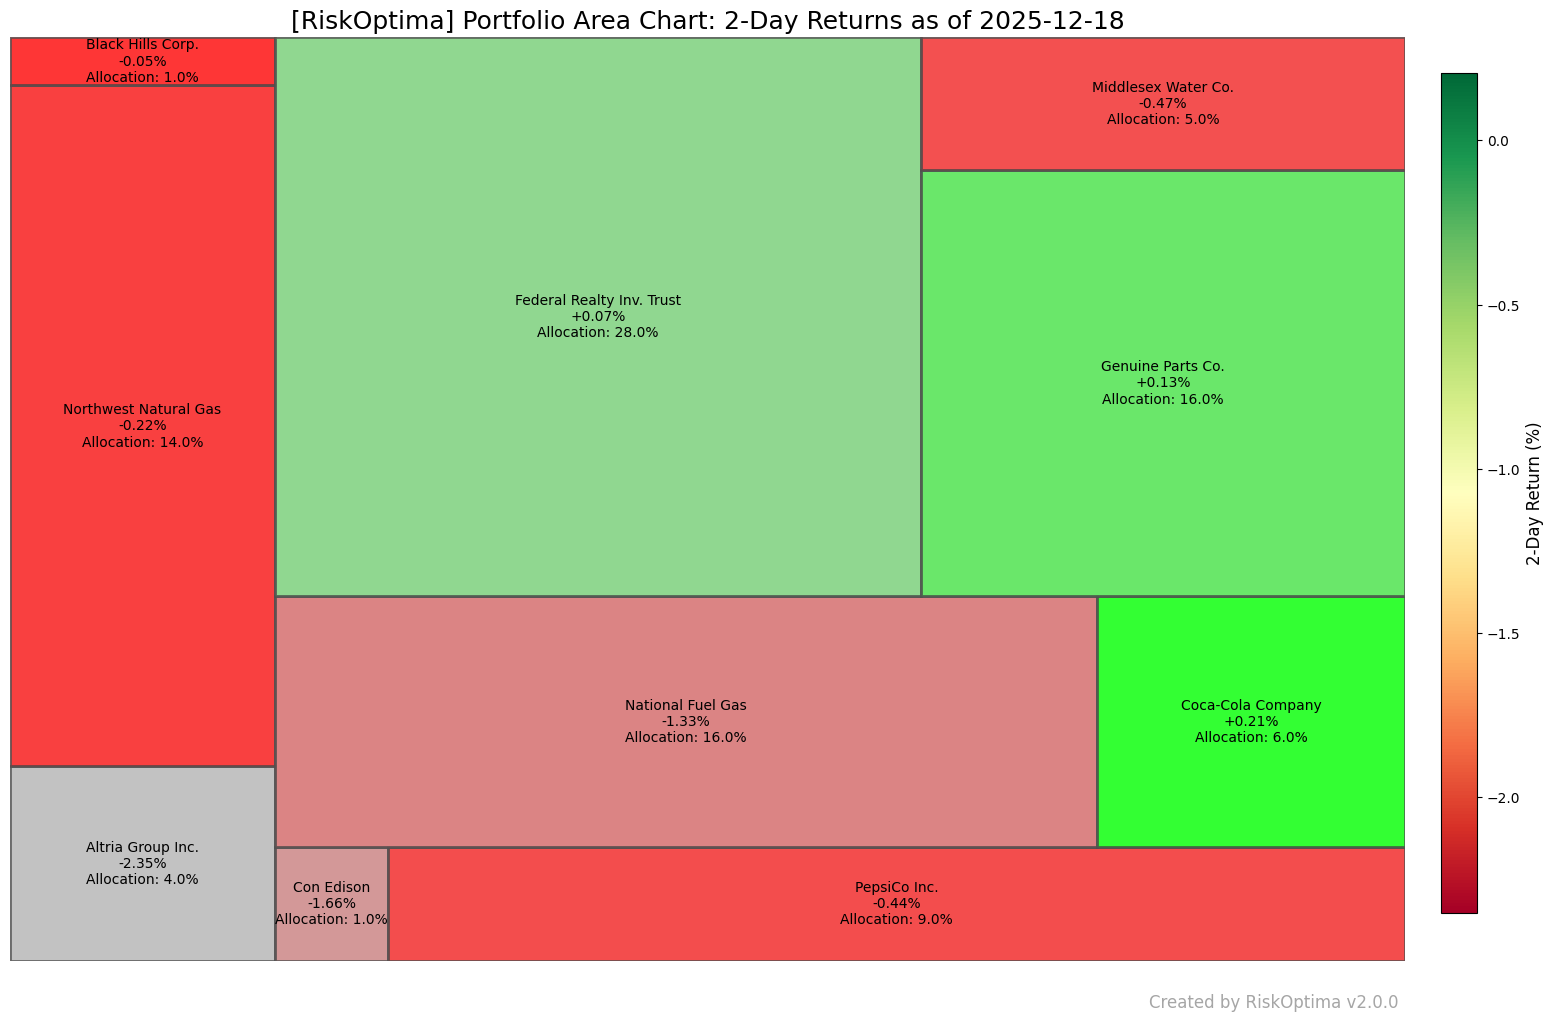

In [7]:
RiskOptima.create_portfolio_area_chart(
    asset_table,
    end_date=ANALYSIS_END_DATE,
    lookback_days=2,
    title="Portfolio Area Chart"
)

## Efficient Frontier with Monte Carlo Simulation

C:\repo\portfolio_risk_kit\riskoptima\riskoptima.py:110: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(assets, start=start_date, end=end_date, progress=False)
C:\repo\portfolio_risk_kit\riskoptima\riskoptima.py:1298: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market_data = yf.download([market_ticker], start=start_date, end=end_date, progress=False)['Close']


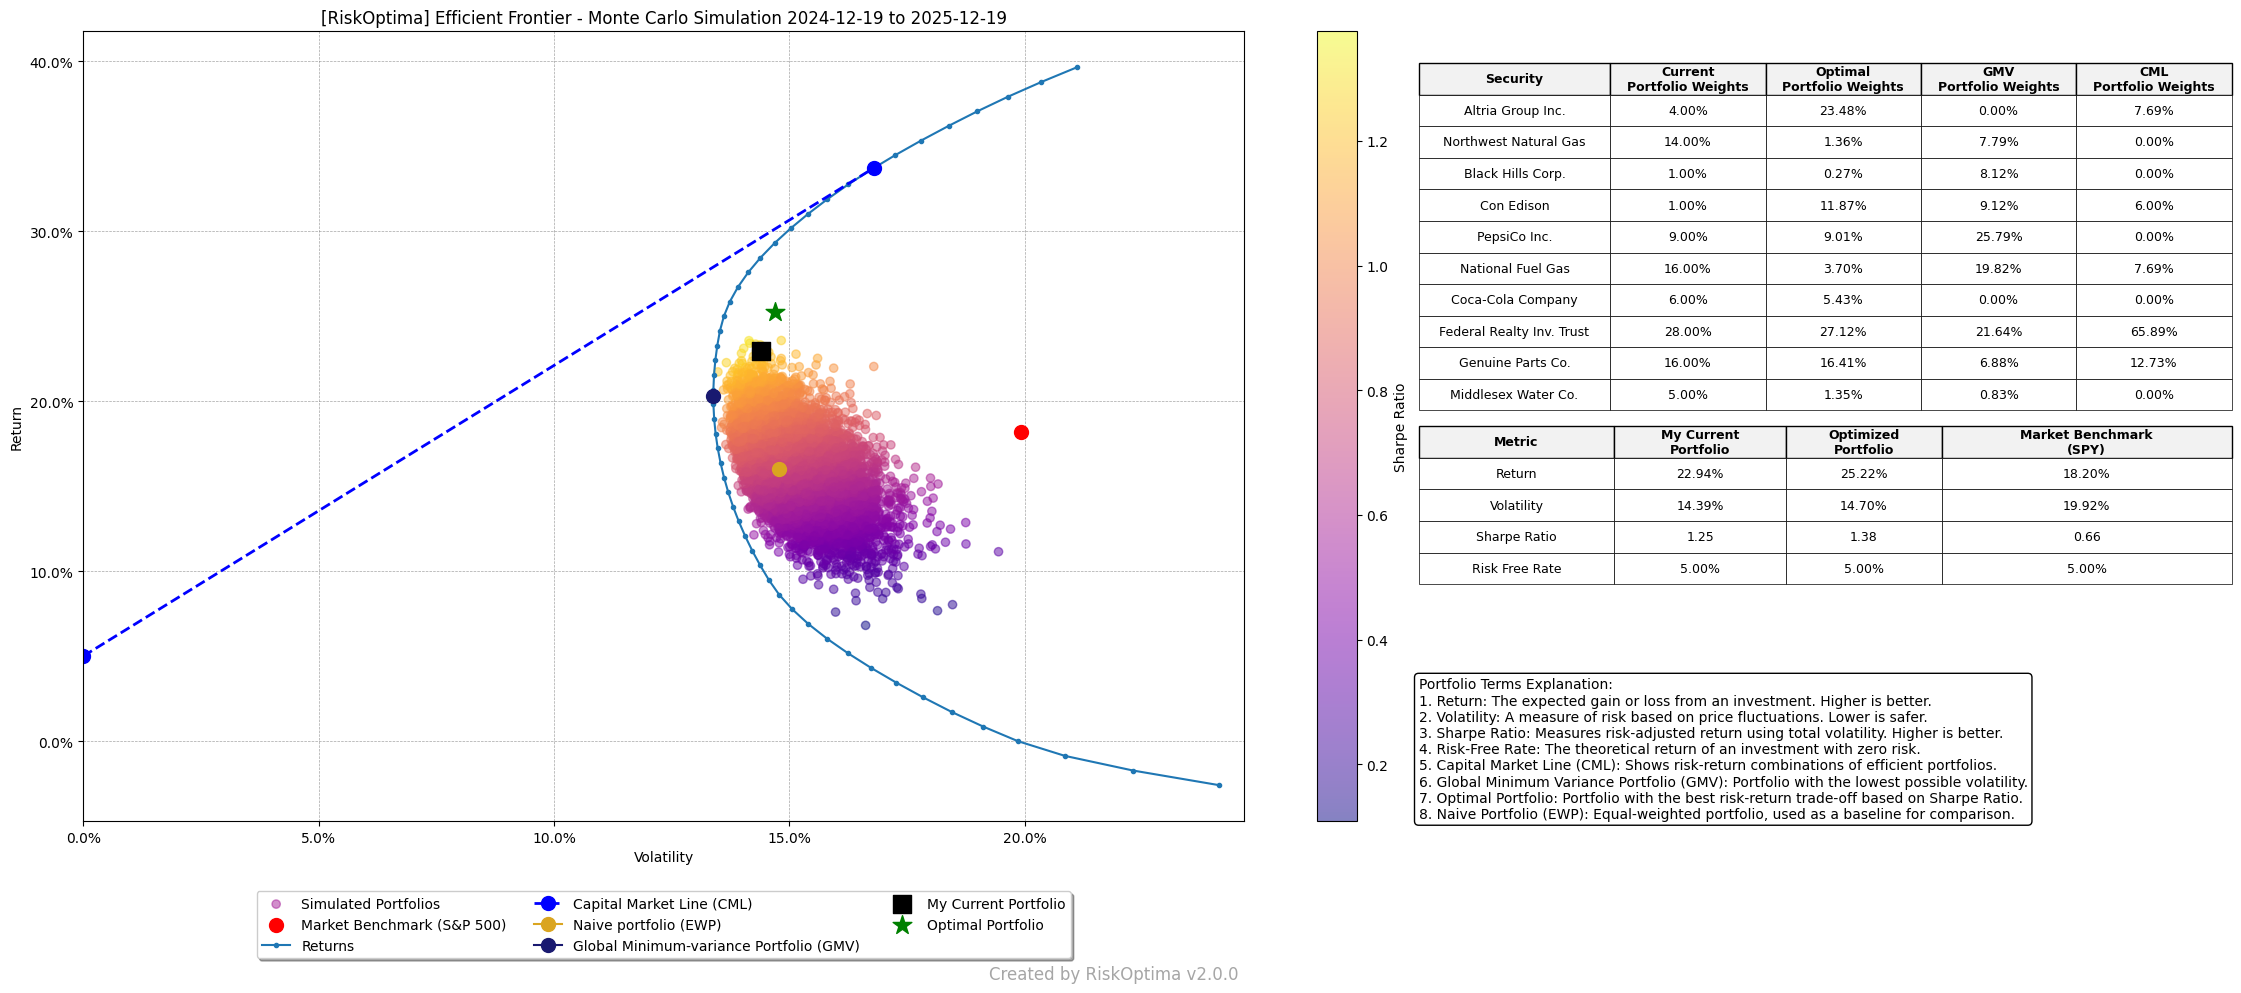

In [10]:
_, _, _ = RiskOptima.plot_efficient_frontier_monte_carlo(
    asset_table,
    start_date=ANALYSIS_START_DATE,
    end_date=ANALYSIS_END_DATE,
    risk_free_rate=RISK_FREE_RATE,
    num_portfolios=NUMBER_OF_WEIGHTS,
    market_benchmark=BENCHMARK_INDEX,
    set_ticks=False,
    x_pos_table=1.15,    # Position for the weight table on the plot
    y_pos_table=0.52,    # Position for the weight table on the plot
)

## Portfolio Optimization using Mean Variance and Machine Learning

C:\repo\portfolio_risk_kit\riskoptima\riskoptima.py:1429: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(tickers, start=start_date, end=end_date, progress=False)
C:\repo\portfolio_risk_kit\riskoptima\riskoptima.py:110: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(assets, start=start_date, end=end_date, progress=False)
C:\repo\portfolio_risk_kit\riskoptima\riskoptima.py:110: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(assets, start=start_date, end=end_date, progress=False)
C:\repo\portfolio_risk_kit\riskoptima\riskoptima.py:110: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(assets, start=start_date, end=end_date, progress=False)
C:\repo\portfolio_risk_kit\riskoptima\riskoptima.py:110: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = 

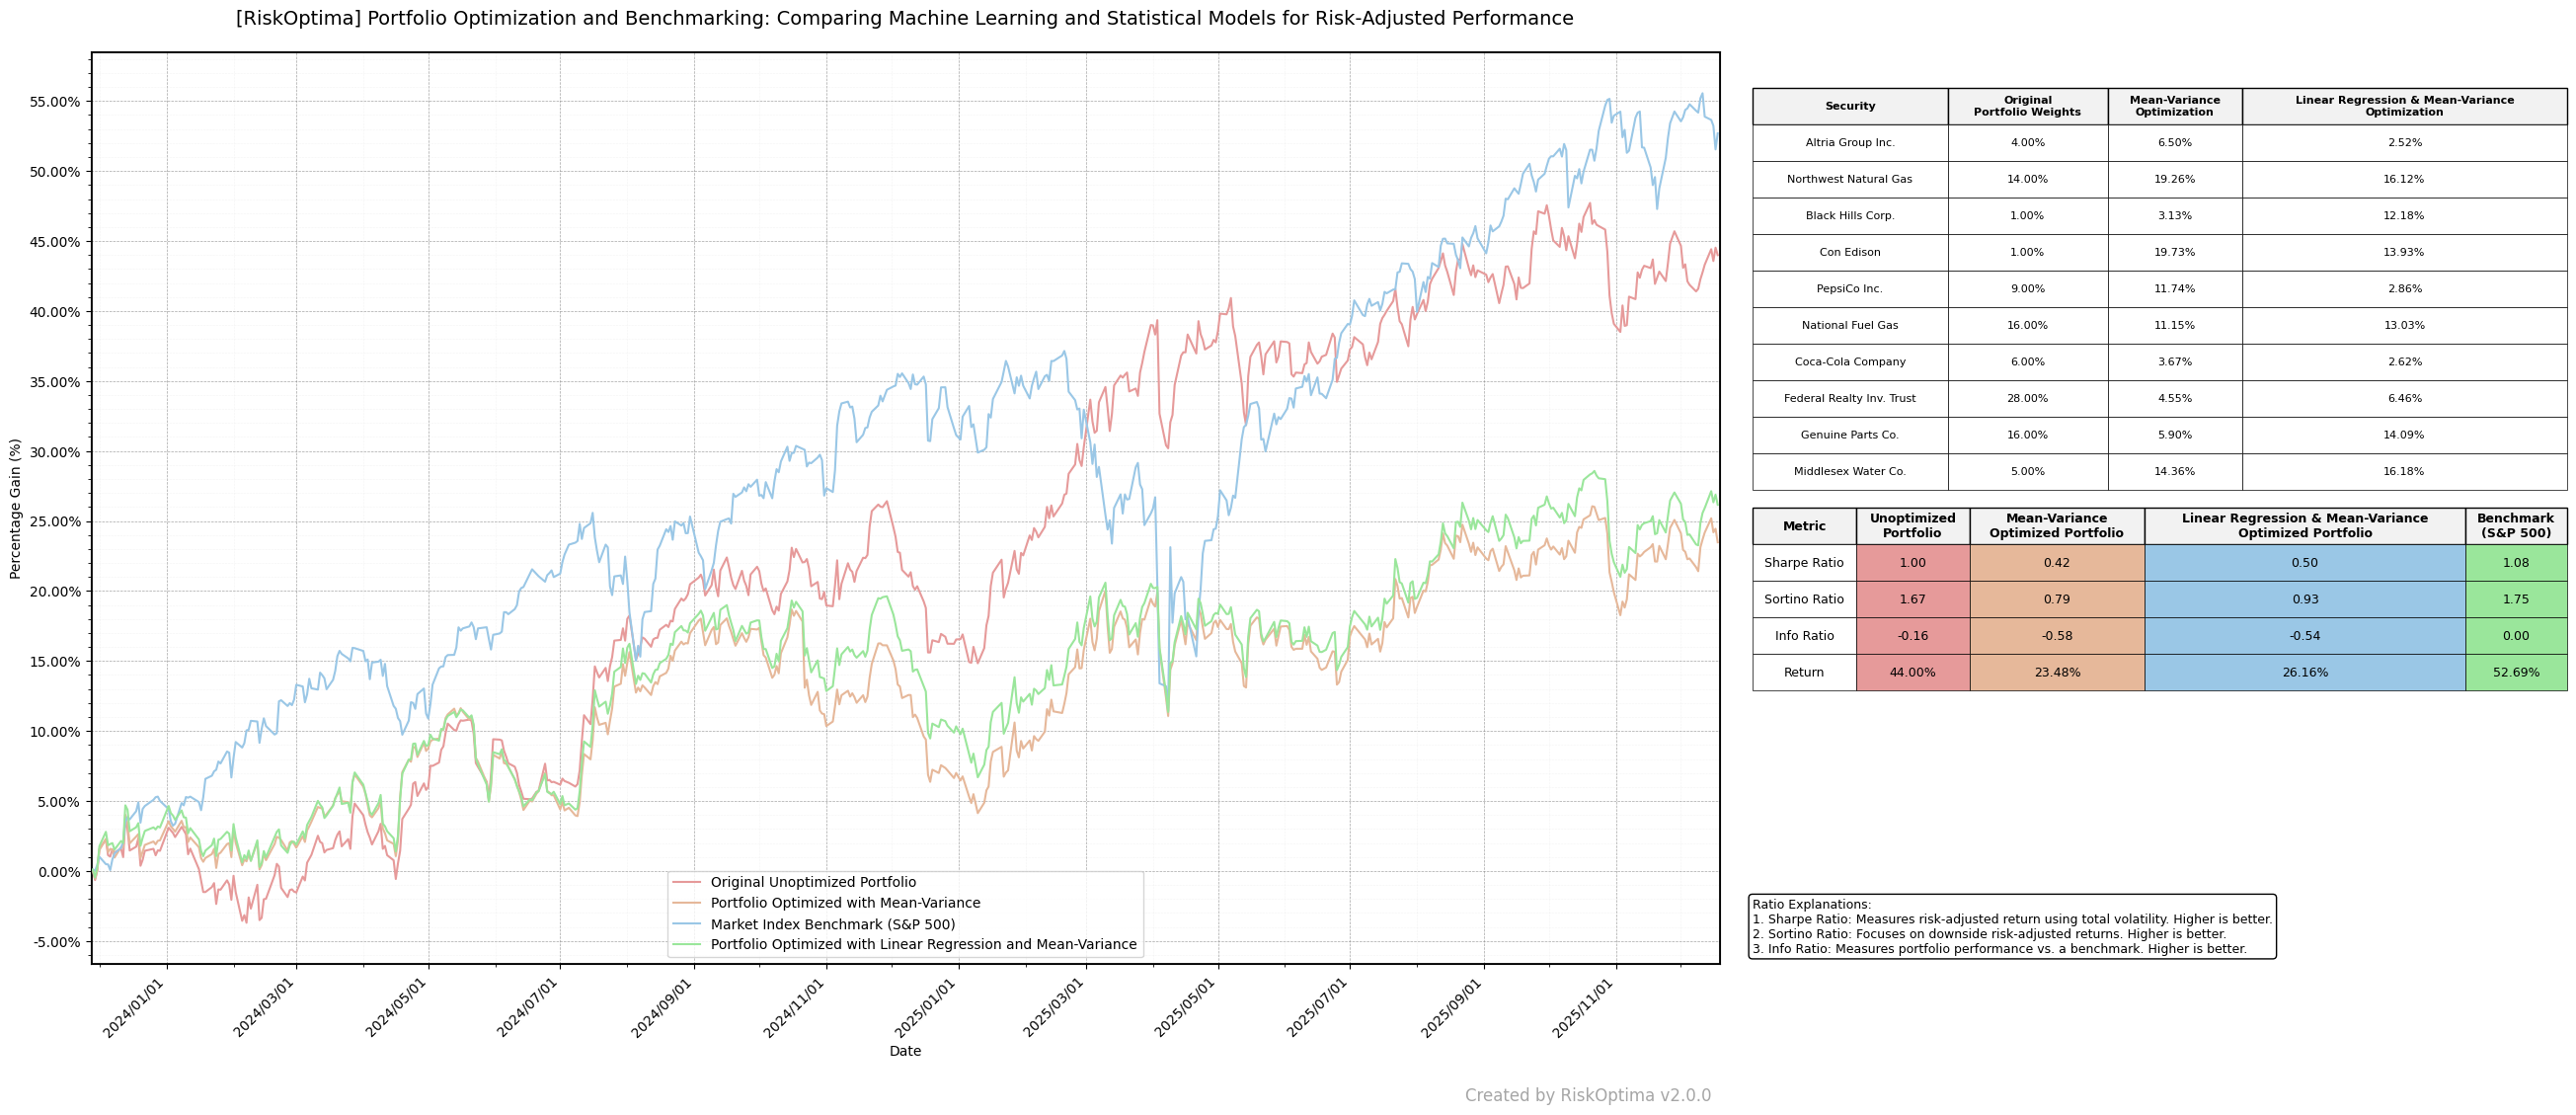

In [15]:
RiskOptima.run_portfolio_optimization_mv_ml(
    asset_table=asset_table,
    training_start_date='2022-01-01',
    training_end_date='2023-11-27',
    model_type='Linear Regression',    
    risk_free_rate=RISK_FREE_RATE,
    num_portfolios=100000,
    market_benchmark=[BENCHMARK_INDEX],
    max_volatility=0.25,
    min_weight=0.03,
    max_weight=0.2
)

## Portfolio Optimization using Probability Analysis

C:\repo\portfolio_risk_kit\riskoptima\riskoptima.py:110: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(assets, start=start_date, end=end_date, progress=False)
C:\repo\portfolio_risk_kit\riskoptima\riskoptima.py:110: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(assets, start=start_date, end=end_date, progress=False)


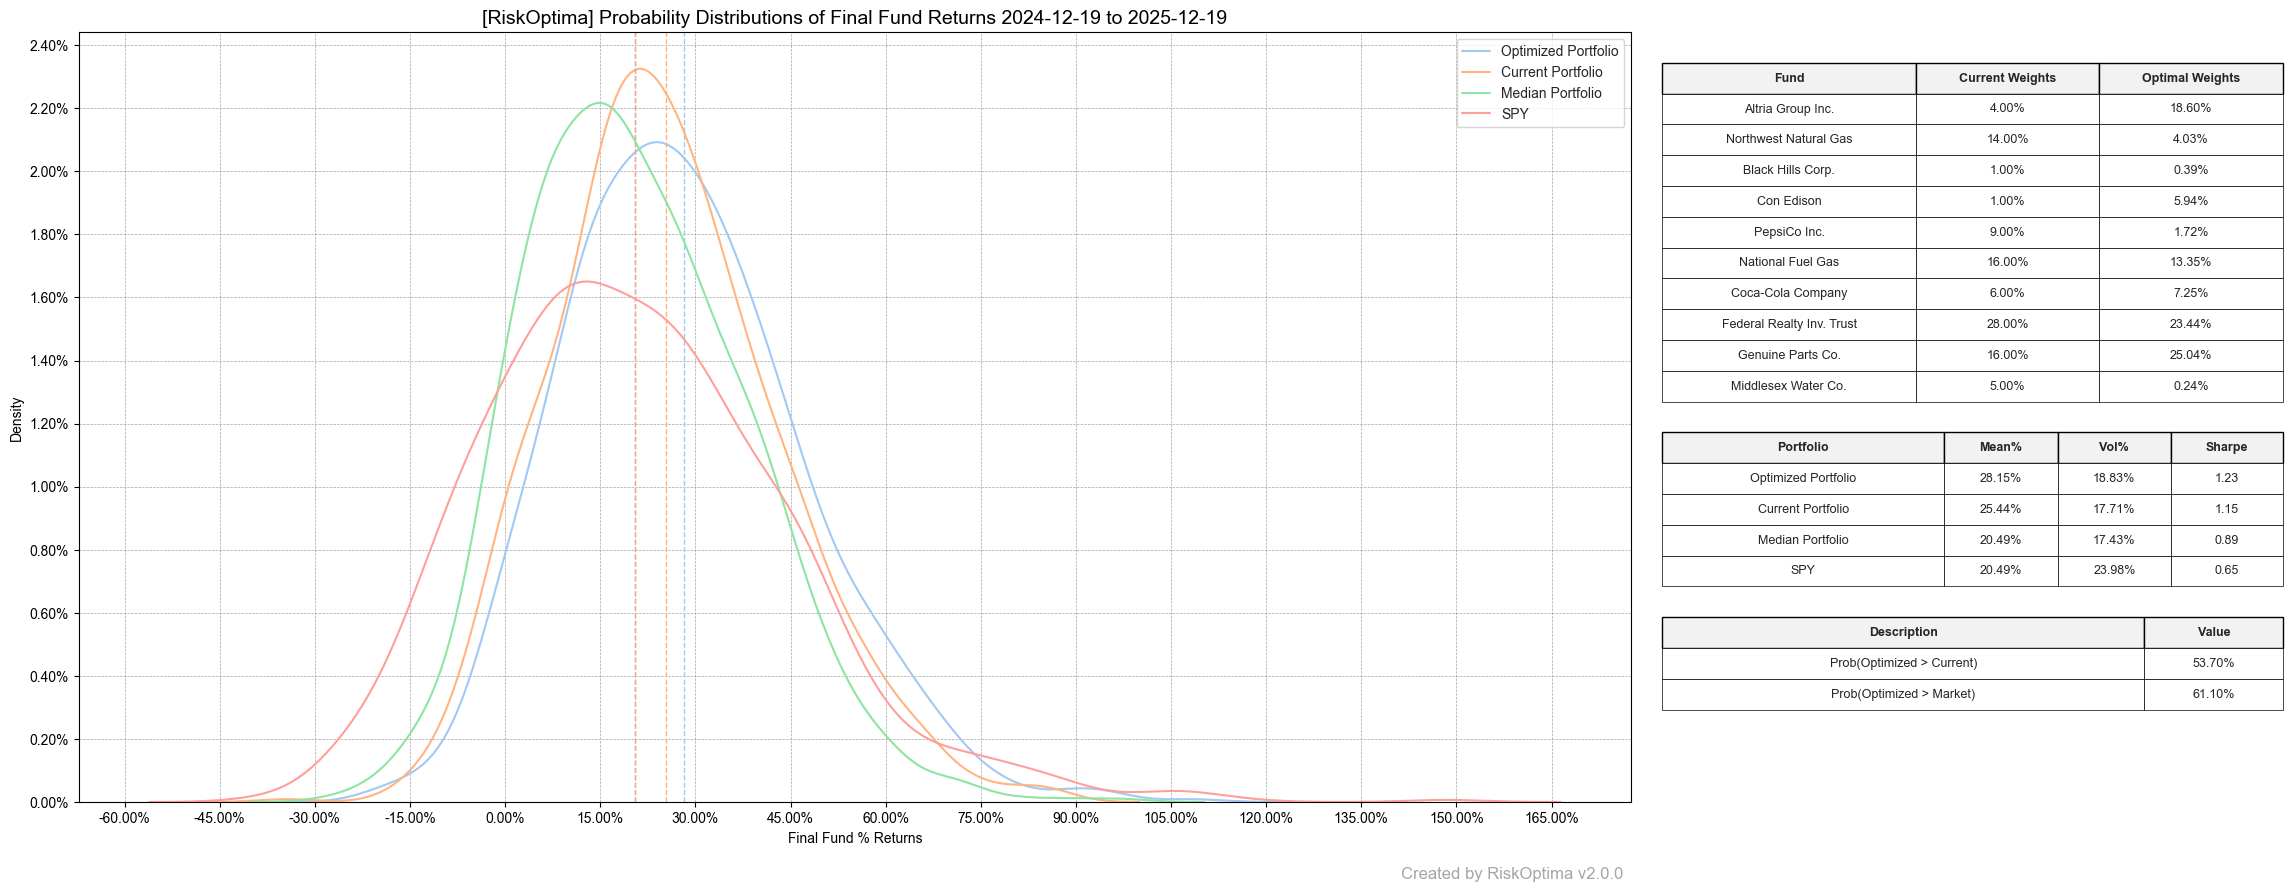

In [17]:
RiskOptima.run_portfolio_probability_analysis(
    asset_table=asset_table,
    analysis_start_date=ANALYSIS_START_DATE,
    analysis_end_date=ANALYSIS_END_DATE,
    benchmark_index=BENCHMARK_INDEX,
    risk_free_rate=RISK_FREE_RATE,
    number_of_portfolio_weights=NUMBER_OF_WEIGHTS,
    trading_days_per_year=RiskOptima.get_trading_days(),
    number_of_monte_carlo_runs=NUMBER_OF_MC_RUNS
)